<a href="https://colab.research.google.com/github/vencov/FAV_upsidedown/blob/main/TutOEME/EX_chirp_time_averaging.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Time-domain averaging of chirp-evoked ear-canal responses

When a chirp stimulus is repeated many times and the ear-canal recording
is cut into one epoch per chirp, the **stimulus-evoked response** is the
same (phase-locked) in every epoch, while the **noise** (physiological,
electronic) is essentially independent from repeat to repeat. Averaging
the epochs together cancels the noise (its amplitude shrinks roughly as
1/√N) while leaving the evoked response untouched — this is the standard
trick used to pull small otoacoustic/ear-canal responses out of a noisy
recording.

This notebook:
1. loads a recording consisting of `Nchirps` repeated chirps back to back,
2. cuts it into individual chirp-length epochs,
3. plots several raw (single-trial) epochs so you can see how noisy any
   *one* chirp response looks,
4. averages across epochs and overlays the averaged response on a single
   raw epoch, so you can see directly how much the noise is reduced.


## 1. Setup

In [83]:
import os
import numpy as np
import matplotlib.pyplot as plt
from scipy.io import loadmat
import urllib.request
from scipy.signal import savgol_filter  # import savitzky golay filter
from scipy.signal.windows import blackman, tukey
plt.rcParams['figure.dpi'] = 100


## 2. Load the data

Set `USE_DEMO_DATA = True` to try the notebook with a synthetic
(simulated) recording — useful for testing the notebook itself before
you have real data, or for a first pass through the exercise.

Set `USE_DEMO_DATA = False` to use your own recording. Your `.mat` file
should contain the same fields as in the lab recordings:
- `y1all`, `y2all` — the two recorded ear-canal channels (one long
  vector each, containing all `Nchirps` repeats back to back)
- `Nsamp` — number of samples per chirp
- `fsamp` — sampling rate (Hz)
- `latSC` — sound-card / system latency to strip from the start (samples)

`Nchirps` (how many chirps were recorded) is **not** stored in the file —
set it below to match your recording protocol.


In [84]:
USE_DEMO_DATA = False  # <-- set to False to load your own .mat file

if USE_DEMO_DATA:
    # ---- synthetic demo recording: a short chirp buried in noise, repeated Nchirps times ----
    from scipy.signal import chirp as make_chirp

    fsamp = 48000.0
    Nsamp = 2000
    latSC = 50
    Nchirps = 300

    rng = np.random.default_rng(0)
    t_chirp = np.arange(Nsamp) / fsamp
    true_response = 0.05 * make_chirp(t_chirp, f0=500, f1=8000, t1=t_chirp[-1], method='linear')

    noise_amp = 0.5
    y1all = np.concatenate([
        np.zeros(latSC),
        np.tile(true_response, Nchirps) + noise_amp * rng.standard_normal(Nchirps * Nsamp)
    ])
    y2all = np.concatenate([
        np.zeros(latSC),
        np.tile(true_response, Nchirps) + noise_amp * rng.standard_normal(Nchirps * Nsamp)
    ])
    print(f"Using synthetic demo data: Nchirps={Nchirps}, Nsamp={Nsamp}, fsamp={fsamp} Hz")

else:
    fname = 'InEarData_tubePok.mat'  # <-- change to your file name

    base_url = "https://raw.githubusercontent.com/vencov/FAV_upsidedown/main/TutOEME/"

    if os.path.exists(fname): # forced to load latest file on github
        os.remove(fname)

    if not os.path.exists(fname):
        urllib.request.urlretrieve(base_url + fname, fname)

    data = loadmat(fname)
    y1all = data['y1all'][0] # response of the first speaker (chirp train)
    y2all = data['y2all'][0] # response of the second speaker (chirp train)
    fsamp = float(data['fsamp'][0][0]) # sampling frequency
    Nsamp = int(data['buffersize'][0][0])  # number of samples i each chirp
    Nchirps = int(data['Nchirps'][0][0])   # number of chirps in the reaponse
    AmpChirp = int(data['AmpChirp'][0][0]) # amplitude of the chirp
    latSC = int(data['lat_SC'][0][0])  # latency of the sound card
    MicGain = int(data['MicGain'][0][0]) # amplitude of the chirp
    Psrc1 = data['Psrc1'][0]  #  Thevenine source pressure
    Psrc2 = data['Psrc2'][0]  #  Thevenine source pressure
    Zsrc1 = data['Zsrc1'][0]  #  Thevenine source impedance
    Zsrc2 = data['Zsrc2'][0]  #  Thevenine source impedance
    fxTS = data['fxTS'][0]  #  frequency axis

    print(f"Loaded '{fname}': Nchirps={Nchirps}, Nsamp={Nsamp}, fsamp={fsamp} Hz")
    print(max(fxTS))

Loaded 'InEarData_tubePok.mat': Nchirps=300, Nsamp=2048, fsamp=44100.0 Hz
17995.0


## 3. Cut the recording into individual chirp epochs

Strip the sound-card latency from the start, then reshape the long
recording into an array of shape `(Nchirps, Nsamp)` — one row per chirp
repeat.


In [85]:
def epoch_chirps(y, latSC, Nsamp, Nchirps):
    '''Strip the initial latency and cut y into Nchirps epochs of Nsamp samples each.'''
    y_stripped = y[latSC:]
    return np.reshape(y_stripped[:Nchirps * Nsamp], (Nchirps, Nsamp))


y1_epochs = epoch_chirps(y1all, latSC, Nsamp, Nchirps)  # shape (Nchirps, Nsamp)
y2_epochs = epoch_chirps(y2all, latSC, Nsamp, Nchirps)

t_ms = np.arange(Nsamp) / fsamp * 1000  # time axis for one epoch, in ms

print(f"y1_epochs shape: {y1_epochs.shape}   (Nchirps x Nsamp)")


y1_epochs shape: (300, 2048)   (Nchirps x Nsamp)


## 4. A few individual (single-trial) chirp responses

Before averaging, look at several individual chirps on their own — this
is what the raw, unaveraged response actually looks like.


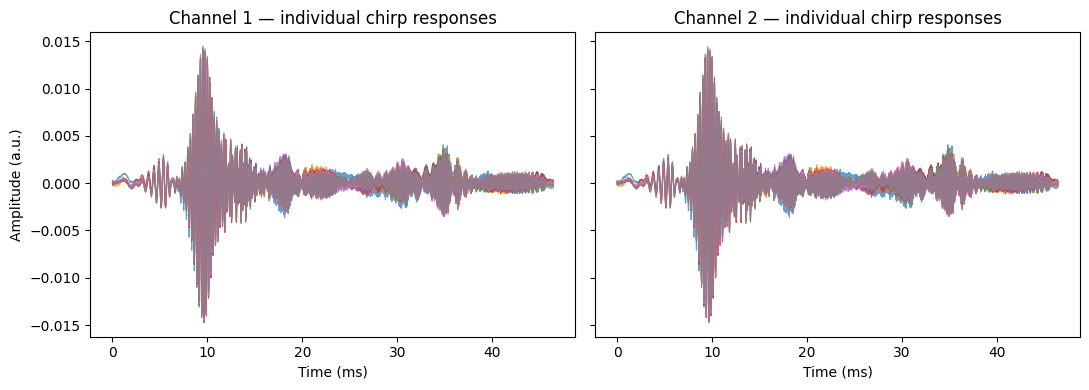

In [86]:
chirps_to_show = np.arange(10, 18)  # 8 example chirps

fig, axs = plt.subplots(1, 2, figsize=(11, 4), sharey=True)
for idx in chirps_to_show:
    axs[0].plot(t_ms, y1_epochs[idx], alpha=0.7, linewidth=0.8)
    axs[1].plot(t_ms, y2_epochs[idx], alpha=0.7, linewidth=0.8)

axs[0].set_title('Channel 1 — individual chirp responses')
axs[1].set_title('Channel 2 — individual chirp responses')
for ax in axs:
    ax.set_xlabel('Time (ms)')
axs[0].set_ylabel('Amplitude (a.u.)')
plt.tight_layout()
plt.show()


## 5. Average across chirps, and compare to a single raw chirp

The first few chirps are skipped (`Nchskip`) to avoid any onset
transient/adaptation at the very start of the stimulus train. The rest
are averaged together and overlaid on one single (unaveraged) chirp
response, so the noise reduction from averaging is directly visible.


Frames to skip: []
Frames to skip: []


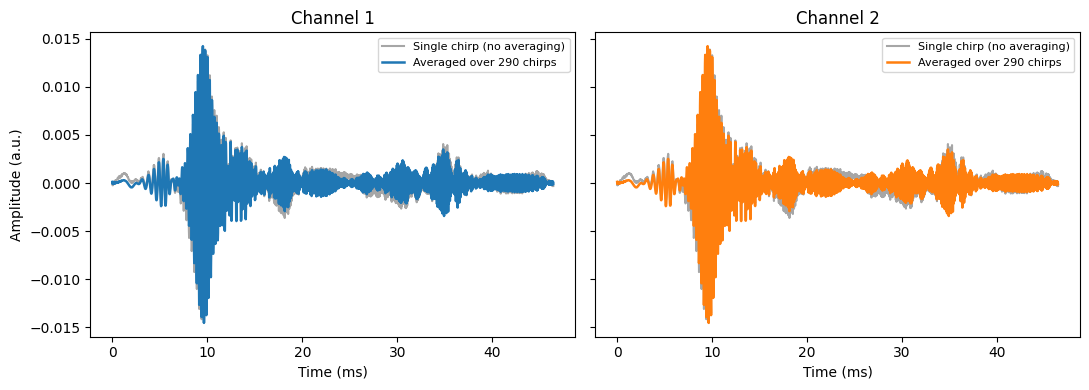

In [88]:
Nchskip = 10  # skip the first few chirps (onset transient), same as in the lab script

y_mean1 = np.mean(y1_epochs[Nchskip:],axis=0)
y_mean2 = np.mean(y2_epochs[Nchskip:],axis=0)

# artifact rejection (reject frams which are affected by some artifact)

y_dev1 = y1_epochs[Nchskip:] - y_mean1
y_dev2 = y2_epochs[Nchskip:] - y_mean2
# Example threshold
threshold = 0.01  # Adjust this based on your criteria

# Compute the maximum absolute deviation for each frame
max_dev_per_frame1 = np.max(np.abs(y_dev1), axis=0)
max_dev_per_frame2 = np.max(np.abs(y_dev2), axis=0)

# Identify frames where the deviation exceeds the threshold
frames_to_skip1 = np.where(max_dev_per_frame1 > threshold)[0]
frames_to_skip2 = np.where(max_dev_per_frame2 > threshold)[0]

print("Frames to skip:", frames_to_skip1)
print("Frames to skip:", frames_to_skip2)

# Select only the columns that are NOT in frames_to_skip
valid_columns1 = np.setdiff1d(np.arange(y1_epochs[Nchskip:].shape[0]), frames_to_skip1)
valid_columns2 = np.setdiff1d(np.arange(y2_epochs[Nchskip:].shape[0]), frames_to_skip2)
# Compute the mean only for the selected columns
y1_avg = np.mean(y1_epochs[Nchskip:][valid_columns1,:], axis=0)
y2_avg = np.mean(y2_epochs[Nchskip:][valid_columns2,:], axis=0)


single_idx = Nchskip  # the first chirp actually used in the average, for a fair comparison

fig, axs = plt.subplots(1, 2, figsize=(11, 4), sharey=True)

axs[0].plot(t_ms, y1_epochs[single_idx], color='gray', alpha=0.7,
            label='Single chirp (no averaging)')
axs[0].plot(t_ms, y1_avg, color='C0', linewidth=1.8,
            label=f'Averaged over {Nchirps - Nchskip} chirps')
axs[0].set_title('Channel 1')

axs[1].plot(t_ms, y2_epochs[single_idx], color='gray', alpha=0.7,
            label='Single chirp (no averaging)')
axs[1].plot(t_ms, y2_avg, color='C1', linewidth=1.8,
            label=f'Averaged over {Nchirps - Nchskip} chirps')
axs[1].set_title('Channel 2')

for ax in axs:
    ax.set_xlabel('Time (ms)')
    ax.legend(loc='upper right', fontsize=8)
axs[0].set_ylabel('Amplitude (a.u.)')
plt.tight_layout()
plt.show()


290
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan


/tmp/ipykernel_1749/2087656944.py:128: RuntimeWarning: divide by zero encountered in divide
  ChResp1 =  np.fft.rfft(y_avg1,NmeanUp1)/(np.fft.rfft(AmpChirp*chirpIn,NmeanUp1))
/tmp/ipykernel_1749/2087656944.py:128: RuntimeWarning: invalid value encountered in divide
  ChResp1 =  np.fft.rfft(y_avg1,NmeanUp1)/(np.fft.rfft(AmpChirp*chirpIn,NmeanUp1))
/tmp/ipykernel_1749/2087656944.py:134: RuntimeWarning: divide by zero encountered in divide
  ChResp2 =  np.fft.rfft(y_avg2,NmeanUp2)/(np.fft.rfft(AmpChirp*chirpIn,NmeanUp2))
/tmp/ipykernel_1749/2087656944.py:134: RuntimeWarning: invalid value encountered in divide
  ChResp2 =  np.fft.rfft(y_avg2,NmeanUp2)/(np.fft.rfft(AmpChirp*chirpIn,NmeanUp2))
/tmp/ipykernel_1749/2087656944.py:159: RuntimeWarning: invalid value encountered in divide
  Zec1 = Zsrc1*Pecs1/(Psrc1 - Pecs1) # impedance of ear canal
/tmp/ipykernel_1749/2087656944.py:160: RuntimeWarning: invalid value encountered in divide
  Zec2 = Zsrc2*Pecs2/(Psrc2 - Pecs2) # impedance of ear ca

nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan


/tmp/ipykernel_1749/2087656944.py:168: RuntimeWarning: invalid value encountered in divide
  Hinear1 = (Pecs1 / (1 + R1))/AmpChirp
/tmp/ipykernel_1749/2087656944.py:169: RuntimeWarning: invalid value encountered in divide
  Hinear2 = (Pecs2 / (1 + R2))/AmpChirp
/tmp/ipykernel_1749/2087656944.py:181: RuntimeWarning: invalid value encountered in divide
  Pfor1 = Pecs1 / (1 + R1)      # forward pressure
/tmp/ipykernel_1749/2087656944.py:183: RuntimeWarning: invalid value encountered in divide
  Rsrc1 = (Zsrc1-Z01)/(Zsrc1+Z01) # probe reflectance


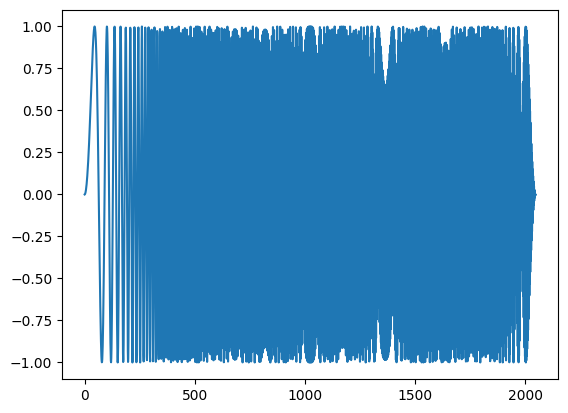

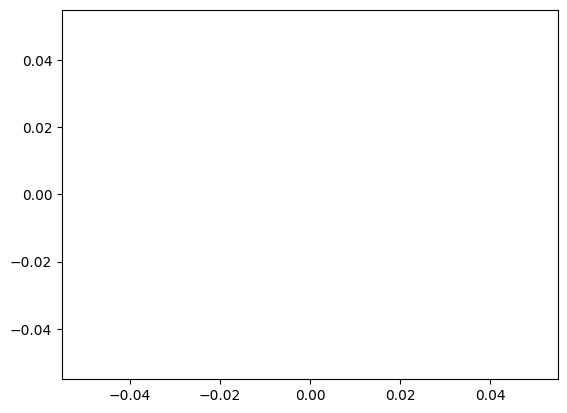

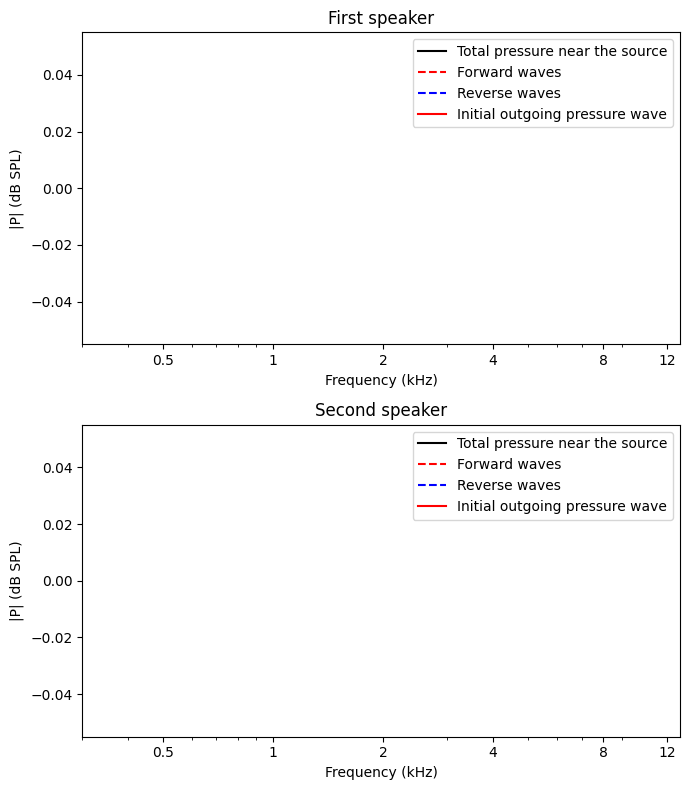

In [89]:


def makeChirp(f1,f2,Nsamp,fsamp):
    '''
    generate a short chirp (linearly swept sine)
    '''
    T = Nsamp/fsamp  # duration of the chirp

    tx = np.arange(0,Nsamp/fsamp,1/fsamp)  # time axis

    A = 1
    T = Nsamp/fsamp

    y = np.zeros_like(tx)
    for k in range(len(tx)):
        y[k] = A*np.sin(2*np.pi*(f1+(f2-f1)/(2*(T))*tx[k])*tx[k])

    return y


def makeChirpTrain(f1,f2,Nsamp,fsamp,Nchirps):
    '''
    generate a train of chirps (linearly swept sines)
    '''

    chirp = makeChirp(f1,f2,Nsamp,fsamp) # make one chirp
    chirptrain = np.tile(chirp,(Nchirps,))  # repeate the chirp Nchirp times

    return chirptrain, chirp




def giveRforTScalibration(Zec,fxPecs,num_iterations=20):
    '''
    function which interatively calculates reflection coeficients from the point of view of the probe
    in the ear canal for calibration purposes
    it is an implementation of the method described in Rasetshwane and Neely (2011) JASA 130:3873
    the method iteratively changes Zsurge in order to decrase reflection coeficients in the time domain
    for t=0
    '''

    # Constants
    rho = 1.1769e-3  # g/cm^3 air density
    eta = 1.846e-4  # g/scm shear viscosity coefficient
    a = 0.8 / 2  # cm radius of tubes
    c = 3.4723e4  # cm/s speed of sound
    k = 1
    kC = 1

    # Parameters for estimation
    #num_iterations = 30
    Fmin = 16e3
    smW = 5

    fsUp = 200000
    fsOrig = 40000

    # Estimation of Zsurge
    for i in range(num_iterations):

        # Initialize Zsurge
        Zsurge = k * rho * c / (np.pi * a ** 2)

        # Reflection coefficient
        R = (Zec - Zsurge) / (Zec + Zsurge)

        # reflection coefficient has samples from 0 to 20kHz, now upsample to 200 kHz
        fxUp = np.linspace(0, fsUp / 2, len(fxPecs) * (fsUp // fsOrig))

        # Zero-pad the frequency spectrum for upsampling
        upsampled_length = len(fxUp)
        Rup = np.pad(R, (0, upsampled_length - len(R)))

        # Make Blackman window
        UpIdx = np.argmax(fxUp >= 17e3)
        if not UpIdx % 2:
            UpIdx += 1

        BMWwidth = UpIdx + UpIdx - 1
        BMwin = blackman(BMWwidth)

        BMwin = BMwin[len(BMwin)//2:]
        BMwinA = np.concatenate((BMwin,np.zeros(len(Rup)-len(BMwin))))

        Rup = BMwinA*Rup

        # Smoothing
        #R = (np.real(R) + 1j * np.imag(R))
        #R = np.convolve(R, np.ones(smW) / smW, mode='same')

    #   Rzeros = np.zeros(4 * len(fxI) // 2)
    #   Rzeros[:len(BMwin) // 2] = np.flipud(BMwin[:len(BMwin) // 2])

        #Rappz = np.concatenate([np.zeros(FminId - 1), R, np.zeros(len(Rzeros) - len(R) - FminId + 1)])
        #fxIex = np.arange(1, len(R) + FminId)
        #fxPex = np.arange(FminId, len(R) + FminId)

        #Rir = interp1d(fxPex, np.real(R), kind='spline', fill_value='extrapolate')(fxIex)
        #Rim = interp1d(fxPex, np.imag(R), kind='spline', fill_value='extrapolate')(fxIex)
        #Rint = Rir + 1j * Rim
        #RappzI = np.concatenate([Rint, np.zeros(len(Rzeros) - len(Rint))])

        #RappzI[0] = np.abs(RappzI[0])
        #Rall = np.concatenate([Rzeros * Rappz, np.flipud(Rzeros[1:]) * np.flipud(np.conj(Rappz[1:]))])
        #RallI = np.concatenate([Rzeros * RappzI, np.flipud(Rzeros[1:]) * np.flipud(np.conj(RappzI[1:]))])

        Rtime = np.fft.irfft(Rup)/2
        RtimeNeg = np.flipud(Rtime)
        RtimeNeg = RtimeNeg[:len(Rtime)//2+1]

        Rtime = Rtime[:len(Rtime)//2+1] + RtimeNeg

        k = k + 40 * Rtime[0]
        print(k)

    return R, Zsurge


# we get the chirp in time domain which was used for measurement
f1 = 0  # start frequency
f2 = fsamp/2 # stop frequency
chirptrain, chirpIn = makeChirpTrain(f1,f2,Nsamp,fsamp,Nchirps)
fig,ax = plt.subplots()
ax.plot(chirpIn)
# calculate spectrum
print(np.size(y1_avg))
Nmean1 = len(y1_avg)  # length of the data
NmeanUp1 = int(2**np.ceil(2+np.log2(Nmean1)))  # interpolated length of the spectrum
ChResp1 =  np.fft.rfft(y1_avg,NmeanUp1)/(np.fft.rfft(AmpChirp*chirpIn,NmeanUp1))
fxCh1 = np.arange(NmeanUp1)*fsamp/NmeanUp1
fxCh1 = fxCh1[:NmeanUp1//2+1]

Nmean2 = len(y2_avg)  # length of the data
NmeanUp2 = int(2**np.ceil(2+np.log2(Nmean2)))  # interpolated length of the spectrum
ChResp2 =  np.fft.rfft(y2_avg,NmeanUp2)/(np.fft.rfft(AmpChirp*chirpIn,NmeanUp2))
fxCh2 = np.arange(NmeanUp2)*fsamp/NmeanUp2
fxCh2 = fxCh2[:NmeanUp2//2+1]

# to smooth out noise, Savitzky-Golay filter is used
ChRespAbs1 = savgol_filter(np.abs(ChResp1), 20, 2)
ChRespImag1 = savgol_filter(np.unwrap(np.angle(ChResp1)), 20, 2)

ChRespAbs2 = savgol_filter(np.abs(ChResp2), 20, 2)
ChRespImag2 = savgol_filter(np.unwrap(np.angle(ChResp2)), 20, 2)


fx = np.arange(100,18e3,5)

ChRespI1 = np.interp(fx,fxCh1,ChRespAbs1)*np.exp(1j*np.interp(fx,fxCh1,ChRespImag1))
ChRespI2 = np.interp(fx,fxCh2,ChRespAbs2)*np.exp(1j*np.interp(fx,fxCh2,ChRespImag2))

#Hinear1 = ChRespI1/(Hoaemic*(10**(MicGain/20))) # convert recorded response to Pascals
#Hinear2 = ChRespI2/(Hoaemic*(10**(MicGain/20)))
Hinear1 = ChRespI1/(0.003*10**(MicGain/20))
Hinear2 = ChRespI2/(0.003*10**(MicGain/20))

Pecs1 = Hinear1*AmpChirp  # pressure in Pascals evoked by the first speaker
Pecs2 = Hinear2*AmpChirp  # pressure in Pascals     evoked by the second speaker

Zec1 = Zsrc1*Pecs1/(Psrc1 - Pecs1) # impedance of ear canal
Zec2 = Zsrc2*Pecs2/(Psrc2 - Pecs2) # impedance of ear canal

fig,ax = plt.subplots()
ax.plot(np.abs(Hinear1))

R1,Z01 = giveRforTScalibration(Zec1,fxTS)
R2,Z02 = giveRforTScalibration(Zec2,fxTS)

Hinear1 = (Pecs1 / (1 + R1))/AmpChirp
Hinear2 = (Pecs2 / (1 + R2))/AmpChirp



# compare figures:
Pfor1,Prev1,Rscr1,Pifw1 = calcPressuresFPL(Pecs1, R1, Zsrc1, Z01)
Pfor2,Prev2,Rscr2,Pifw2 = calcPressuresFPL(Pecs2, R2, Zsrc2, Z02)


def calcPressuresFPL(Pecs1,R1,Zsrc1,Z01):


    Pfor1 = Pecs1 / (1 + R1)      # forward pressure
    Prev1 = R1*Pfor1               # reverse pressure
    Rsrc1 = (Zsrc1-Z01)/(Zsrc1+Z01) # probe reflectance
    Pifw1 = Pfor1*(1-R1*Rsrc1)    # initial pressure wave

    return Pfor1,Prev1,Rsrc1,Pifw1



refP = np.sqrt(2)*2e-5  # reference pressure
fig,(ax1,ax2) = plt.subplots(2,1, figsize=(7,8))
from matplotlib.ticker import ScalarFormatter
# --- First speaker ---
ax1.semilogx(fxTS/1e3,20*np.log10(np.abs(Pecs1/refP)),'k',label="Total pressure near the source")
ax1.semilogx(fxTS/1e3,20*np.log10(np.abs(Pfor1/refP)),'r--',label="Forward waves")
ax1.semilogx(fxTS/1e3,20*np.log10(np.abs(Prev1/refP)),'b--',label="Reverse waves")
ax1.semilogx(fxTS/1e3,20*np.log10(np.abs(Pifw1/refP)),'r',label="Initial outgoing pressure wave")
ax1.set_xlabel('Frequency (kHz)')
ax1.set_ylabel('|P| (dB SPL)')
ax1.set_title("First speaker")
ax1.set_xlim((0.3, 13))
ax1.legend()  # legend for first subplot

# Format x-axis ticks in kHz, not scientific notation
ax1.xaxis.set_major_formatter(ScalarFormatter())
ax1.set_xticks([0.5, 1, 2, 4, 8, 12])
ax1.set_xticklabels(['0.5', '1', '2', '4', '8', '12'])

# --- Second speaker ---
ax2.semilogx(fxTS/1e3,20*np.log10(np.abs(Pecs2/refP)),'k',label="Total pressure near the source")
ax2.semilogx(fxTS/1e3,20*np.log10(np.abs(Pfor2/refP)),'r--',label="Forward waves")
ax2.semilogx(fxTS/1e3,20*np.log10(np.abs(Prev2/refP)),'b--',label="Reverse waves")
ax2.semilogx(fxTS/1e3,20*np.log10(np.abs(Pifw2/refP)),'r',label="Initial outgoing pressure wave")
ax2.set_xlabel('Frequency (kHz)')
ax2.set_ylabel('|P| (dB SPL)')
ax2.set_title("Second speaker")
ax2.set_xlim((0.3, 13))
ax2.legend()  # legend for second subplot

# Format x-axis ticks in kHz, not scientific notation
ax2.xaxis.set_major_formatter(ScalarFormatter())
ax2.set_xticks([0.5, 1, 2, 4, 8, 12])
ax2.set_xticklabels(['0.5', '1', '2', '4', '8', '12'])

plt.tight_layout()

